## 二维势阱模型采样

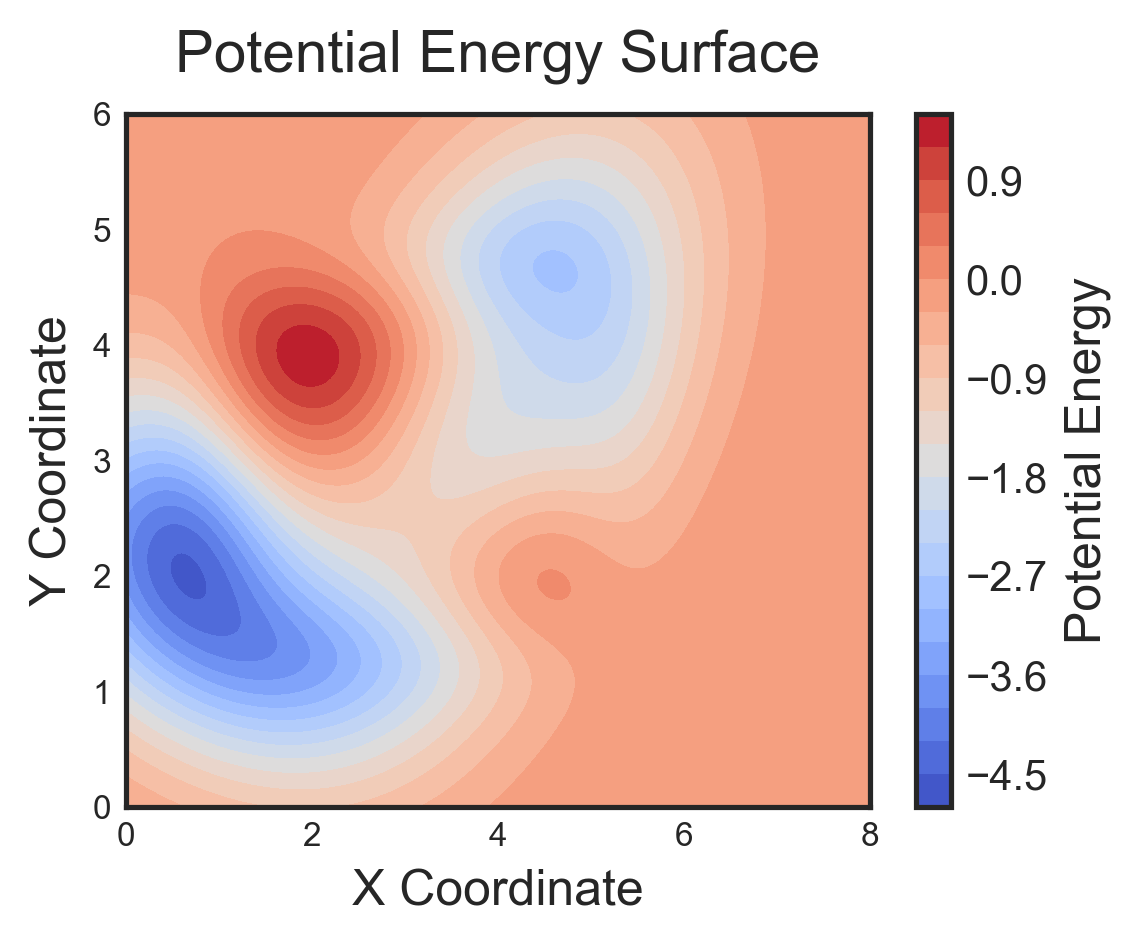

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os

def potential_energy(x, y):
    # 盆底1参数 (左下方)
    A1 = 5.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    x1, y1 = 1.0, 2.0
    
    # 盆底2参数 (右上方)
    A2 = 4.5
    a2, b2, c2 = 0.4, 0.3, -0.3
    x2, y2 = 4.0, 3.5
    
    # 中央势垒参数
    B = 3.0
    x0, y0 = 3, 3.0
    sigma_x, sigma_y = 2.0, 1.5
    
    
    # 计算各组成部分
    well1 = -A1 * np.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * np.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    barrier = B * np.exp(-(x-x0)**4/sigma_x**4 - (y-y0)**4/sigma_y**4)
    
    return well1 + well2 + barrier 

x = np.linspace(0, 8, 200)
y = np.linspace(0, 6, 200)
X, Y = np.meshgrid(x, y)
Z = potential_energy(X, Y)

os.makedirs('figures', exist_ok=True)
# plt.style.use('seaborn-white')
fig, ax = plt.subplots(figsize=(4, 3))

# 绘制等高线图
contour = ax.contourf(X, Y, Z, levels=20, cmap=cm.coolwarm)
cbar = fig.colorbar(contour, ax=ax, pad=0.05)
cbar.set_label('Potential Energy', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_title('Potential Energy Surface', fontsize=14, pad=10)


# 保存为TIFF格式
plt.savefig('figures/b-2d-well.tiff', format='tiff', dpi=300)
plt.show()

## Random sampling to obtain VAE train data

In [27]:
import numpy as np
import pandas as pd
import os

def potential_energy(x, y):
    # 盆底1参数 (左下方)
    A1 = 5.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    x1, y1 = 1.0, 2.0
    
    # 盆底2参数 (右上方)
    A2 = 4.5
    a2, b2, c2 = 0.4, 0.3, -0.3
    x2, y2 = 4.0, 3.5
    
    # 中央势垒参数
    B = 3.0
    x0, y0 = 3, 3.0
    sigma_x, sigma_y = 2.0, 1.5
    
    # 计算各组成部分
    well1 = -A1 * np.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * np.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    barrier = B * np.exp(-(x-x0)**4/sigma_x**4 - (y-y0)**4/sigma_y**4)
    
    return well1 + well2 + barrier

# 创建data目录（如果不存在）
os.makedirs('data', exist_ok=True)

# 生成1000个随机点
np.random.seed(42)  # 设置随机种子保证可重复性
x_samples = np.random.uniform(0, 8, 1000)
y_samples = np.random.uniform(0, 6, 1000)
z_samples = potential_energy(x_samples, y_samples)

# 创建DataFrame并保存为CSV
data = pd.DataFrame({
    'X': x_samples,
    'Y': y_samples,
    'Potential_Energy': z_samples
})

# 保存到CSV文件
data.to_csv('data/data-1-vae.csv', index=False, float_format='%.6f')

print("数据已保存到 data/data-1-vae.csv")
print(data.head())  # 打印前5行数据预览

数据已保存到 data/data-1-vae.csv
          X         Y  Potential_Energy
0  2.996321  1.110798         -2.324661
1  7.605714  3.251406         -0.018615
2  5.855952  5.237675         -1.206398
3  4.789268  4.393349         -2.660737
4  1.248149  4.839367          0.055832


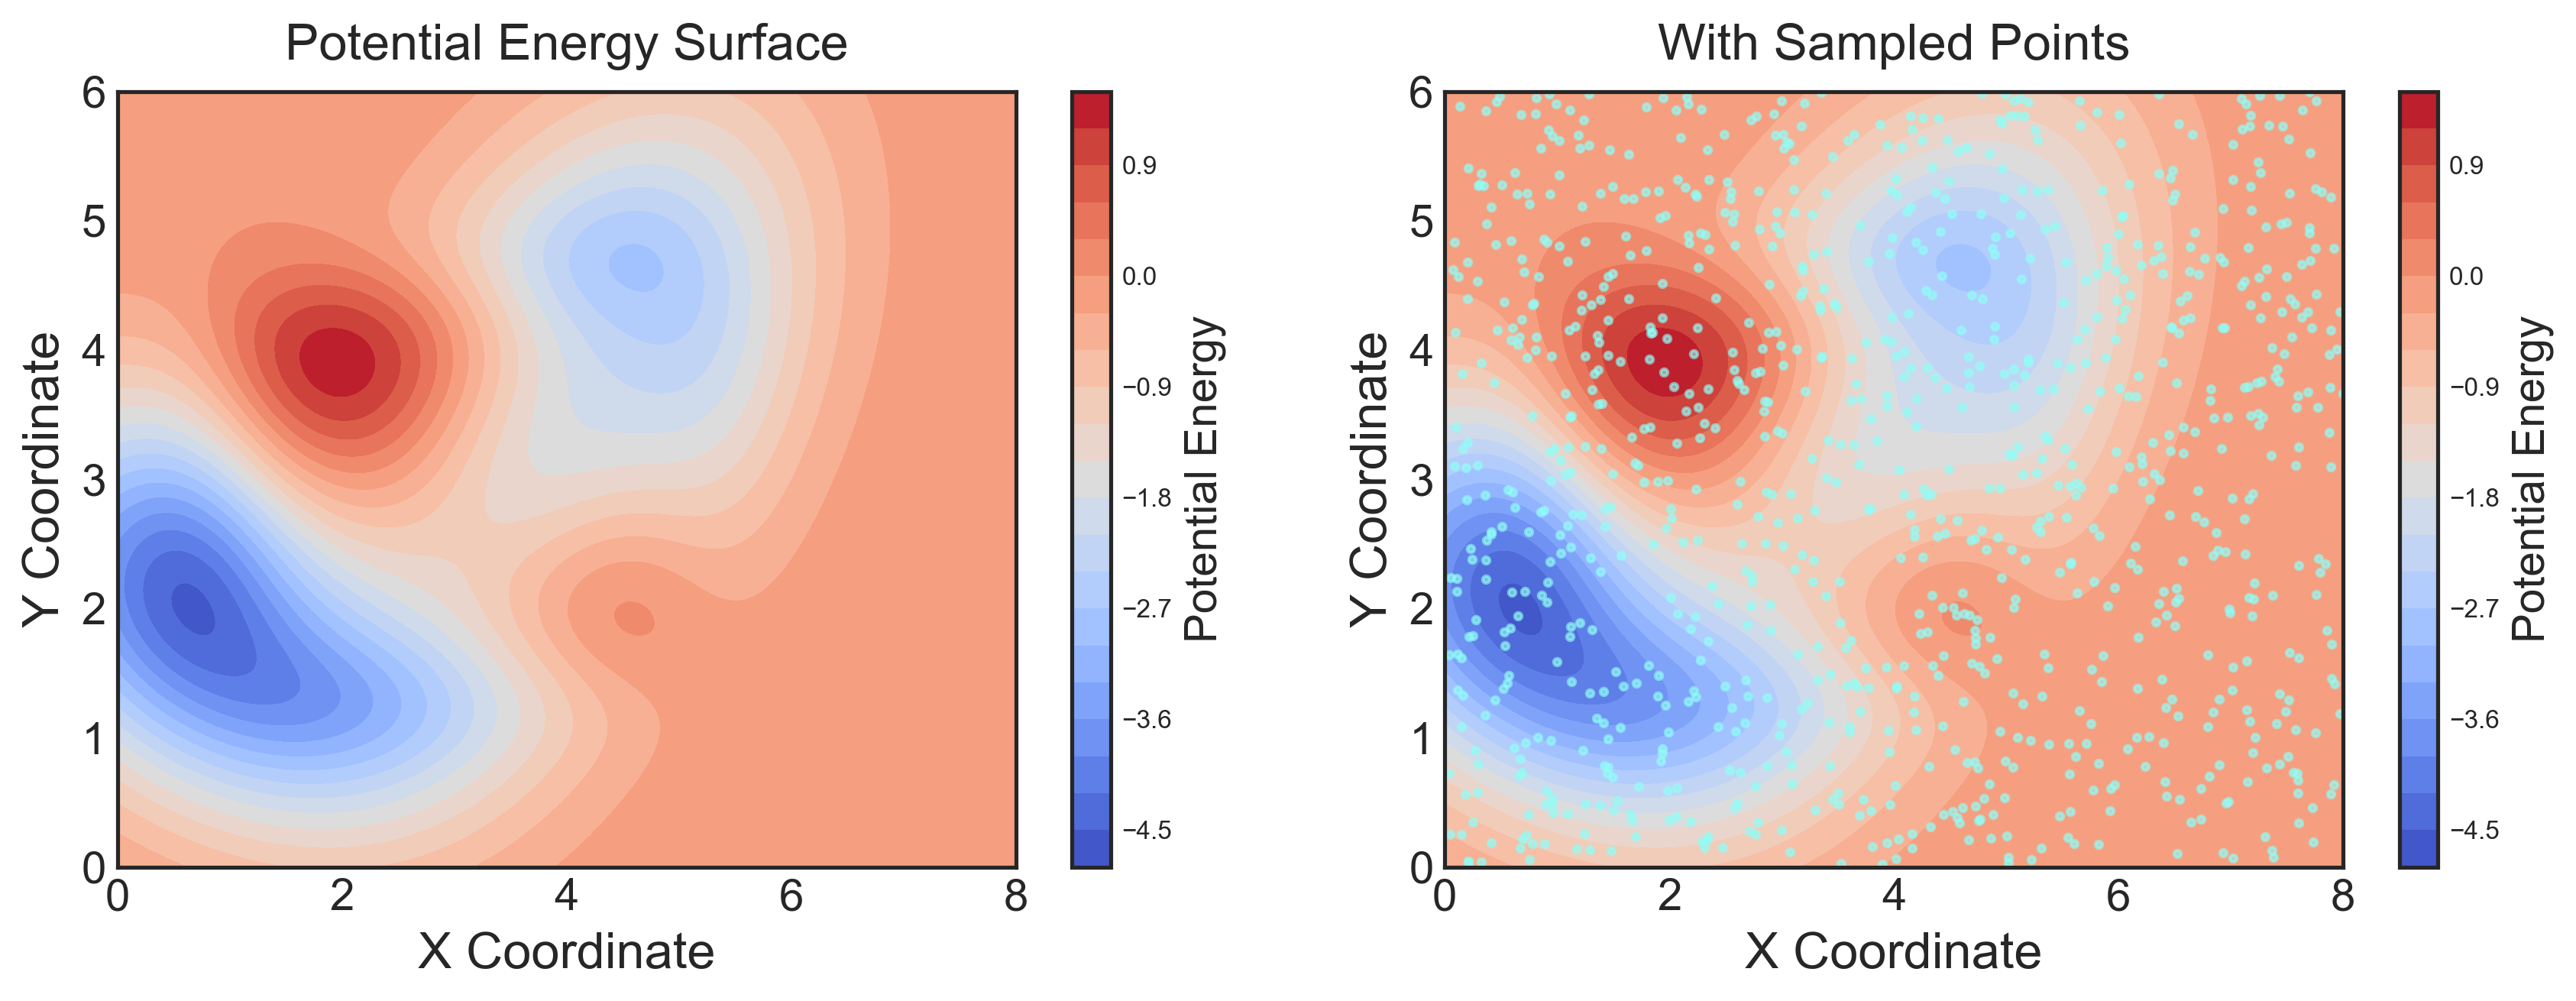

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import os

def potential_energy(x, y):
    # 盆底1参数 (左下方)
    A1 = 5.0
    a1, b1, c1 = 0.3, 0.5, 0.2
    x1, y1 = 1.0, 2.0
    
    # 盆底2参数 (右上方)
    A2 = 4.5
    a2, b2, c2 = 0.4, 0.3, -0.3
    x2, y2 = 4.0, 3.5
    
    # 中央势垒参数
    B = 3.0
    x0, y0 = 3, 3.0
    sigma_x, sigma_y = 2.0, 1.5
    
    # 计算势能
    well1 = -A1 * np.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * np.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    barrier = B * np.exp(-(x-x0)**4/sigma_x**4 - (y-y0)**4/sigma_y**4)
    
    return well1 + well2 + barrier

# 读取数据
data = pd.read_csv('data/data-1-vae.csv')
x_samples, y_samples = data['X'].values, data['Y'].values

# 创建网格
x = np.linspace(0, 8, 200)
y = np.linspace(0, 6, 200)
X, Y = np.meshgrid(x, y)
Z = potential_energy(X, Y)

# 创建一行两列的子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), 
                              gridspec_kw={'width_ratios': [1, 1]})

# 左侧子图：纯势能面
contour1 = ax1.contourf(X, Y, Z, levels=20, cmap=cm.coolwarm)
cbar1 = fig.colorbar(contour1, ax=ax1, pad=0.05)
cbar1.set_label('Potential Energy', fontsize=14)
ax1.set_title('Potential Energy Surface', fontsize=16, pad=10)

# 右侧子图：带采样点的势能面
contour2 = ax2.contourf(X, Y, Z, levels=20, cmap=cm.coolwarm)
ax2.scatter(x_samples, y_samples, color="#91FEF7", s=5, alpha=0.6)
cbar2 = fig.colorbar(contour2, ax=ax2, pad=0.05)
cbar2.set_label('Potential Energy', fontsize=14)
ax2.set_title('With Sampled Points', fontsize=16, pad=10)

# 统一设置坐标轴
for ax in [ax1, ax2]:
    ax.set_xlabel('X Coordinate', fontsize=16)
    ax.set_ylabel('Y Coordinate', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)

# 调整布局并保存
plt.tight_layout(pad=3.0)
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/data-vae_panel_surface.tiff', 
           format='tiff', dpi=300, bbox_inches='tight')
plt.show()

No handles with labels found to put in legend.


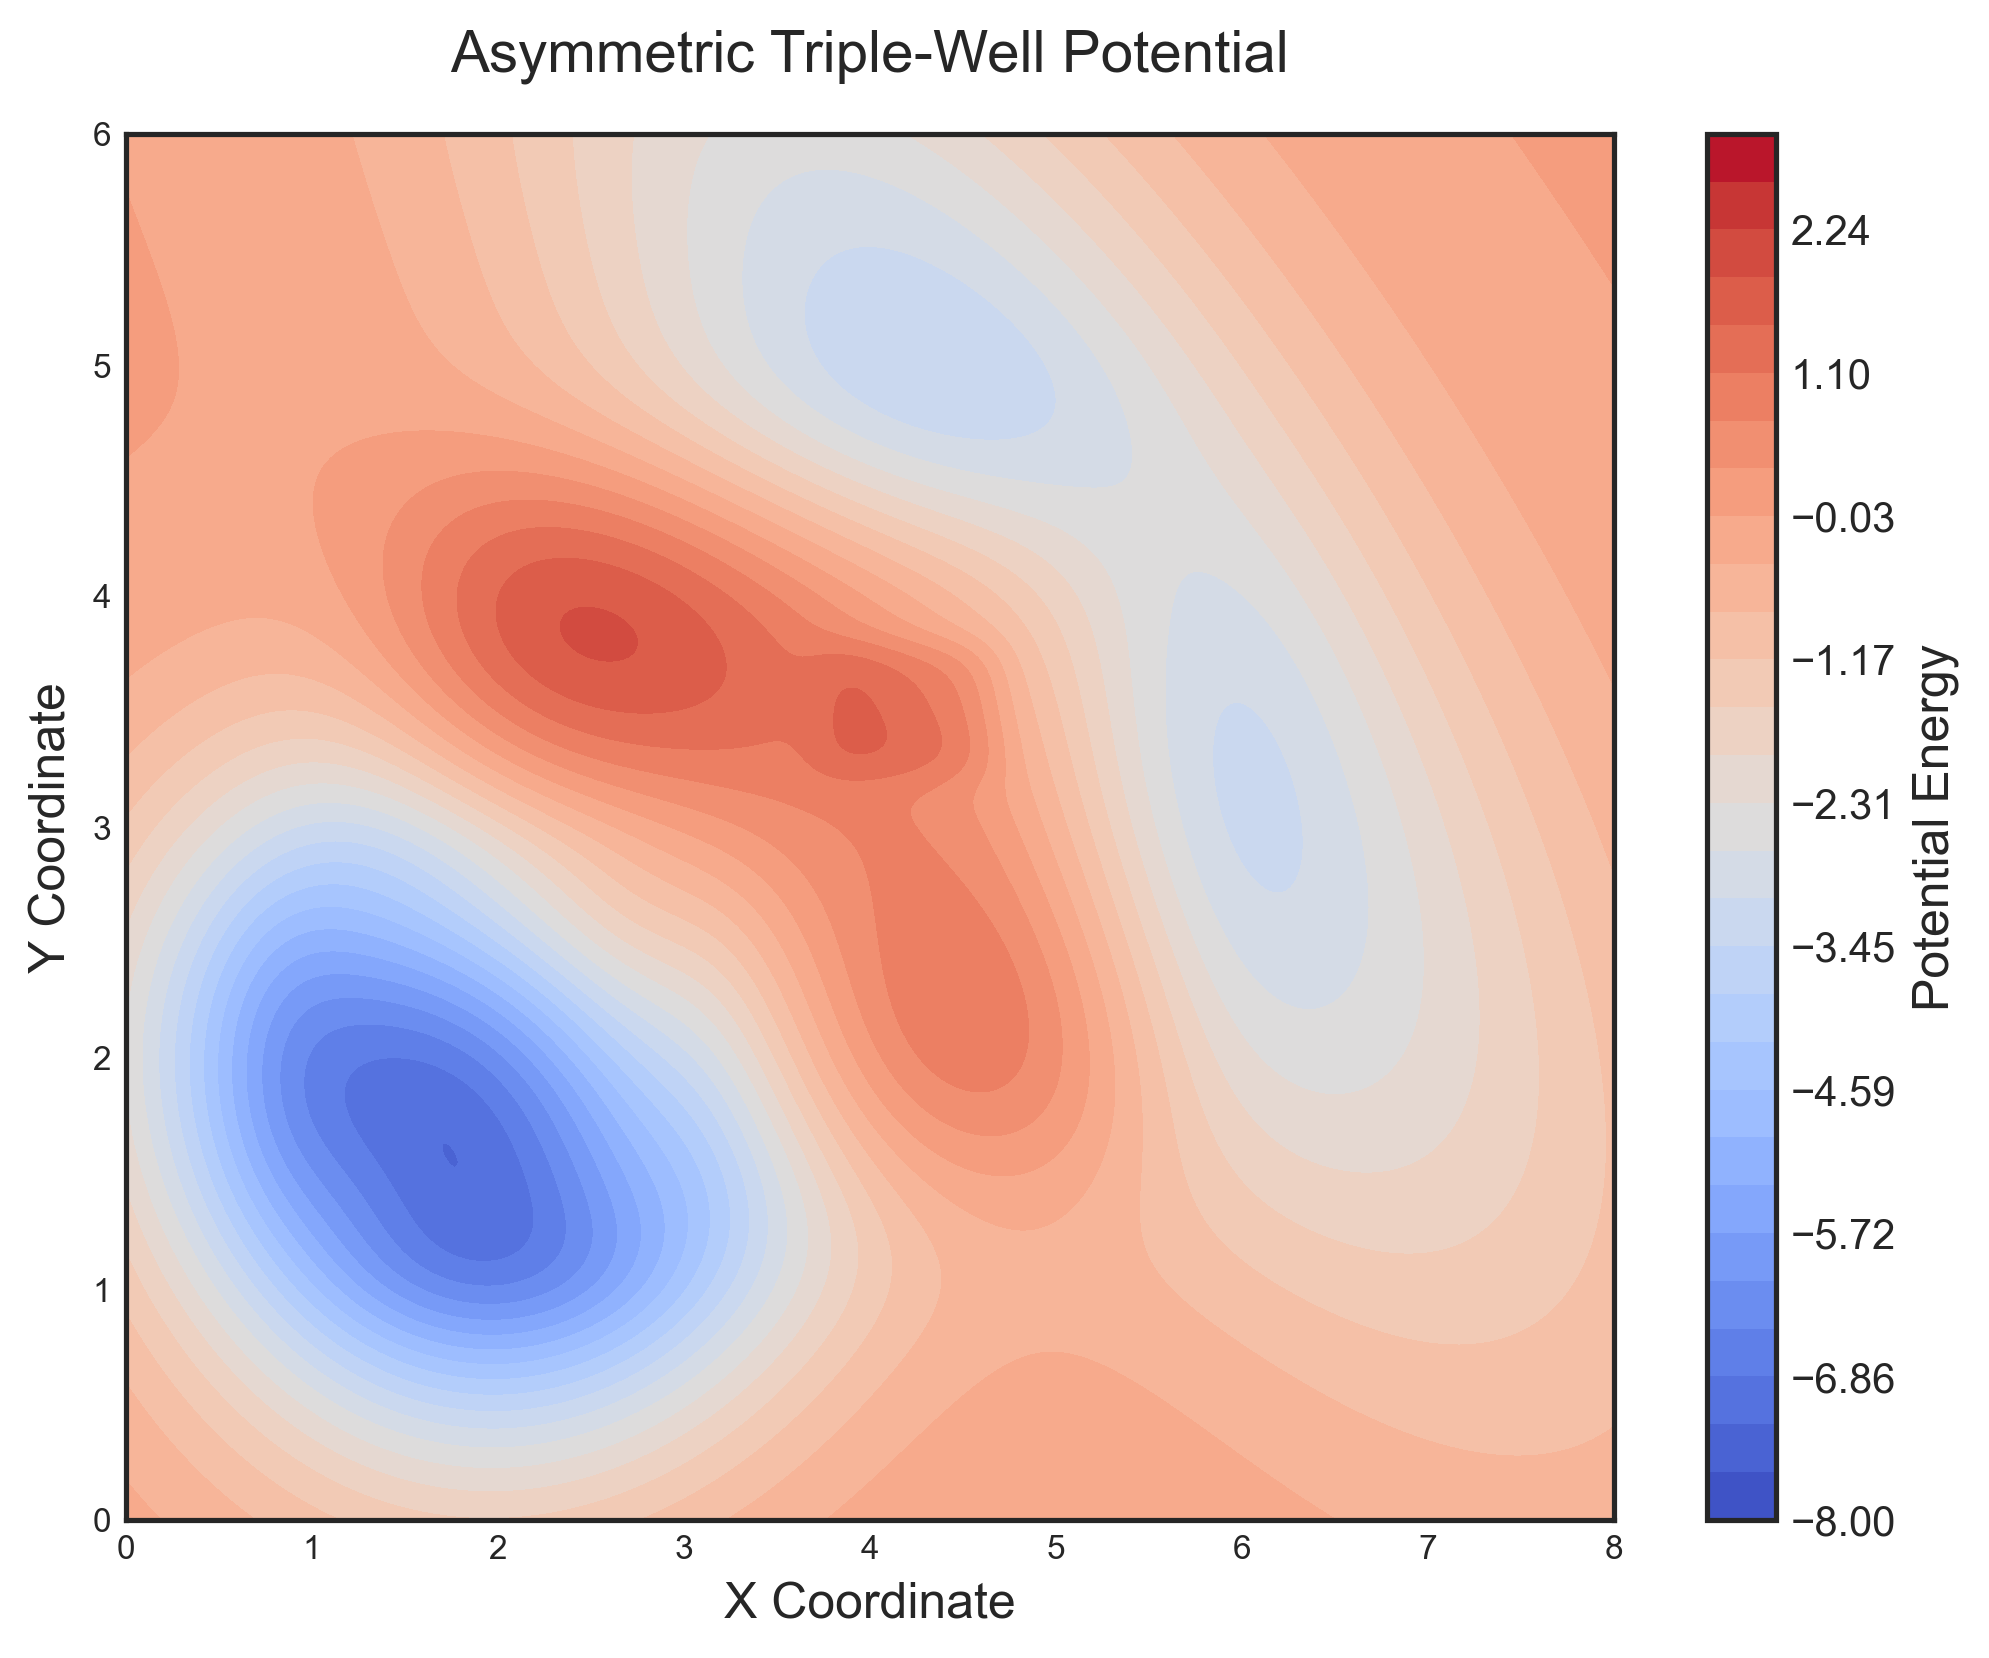

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os

def potential_energy(x, y):
    # 左盆地1 (深且窄)
    A1 = 6.0
    a1, b1, c1 = 0.5, 0.7, 0.1
    x1, y1 = 1.5, 2.0
    
    # 左盆地2 (中等深度，靠近盆地1)
    A2 = 5.5
    a2, b2, c2 = 0.4, 0.5, -0.2
    x2, y2 = 2.5, 1.8
    
    # 右上方盆地 (浅且宽)
    A3 = 4.0
    a3, b3, c3 = 0.3, 0.25, 0.4
    x3, y3 = 5.0, 4.0
    
    # 盆地1和2之间的低势垒
    B_low = 1.5
    barrier_low = B_low * np.exp(-(x-2.0)**4/1.0**4 - (y-2.0)**4/0.8**4)
    
    # 左盆地和右盆地之间的高势垒
    B_high = 4.0
    barrier_high = B_high * np.exp(-(x-3.5)**4/2.0**4 - (y-3.0)**4/1.5**4)
    
    # 右盆地附近的窄低势垒
    B_narrow = 0.8
    barrier_narrow = B_narrow * np.exp(-(x-4.2)**4/0.5**4 - (y-3.5)**4/0.3**4)
    
    # 计算各盆地
    well1 = -A1 * np.exp(-a1*(x-x1)**2 - b1*(y-y1)**2 - c1*(x-x1)*(y-y1))
    well2 = -A2 * np.exp(-a2*(x-x2)**2 - b2*(y-y2)**2 - c2*(x-x2)*(y-y2))
    well3 = -A3 * np.exp(-a3*(x-x3)**2 - b3*(y-y3)**2 - c3*(x-x3)*(y-y3))
    
    return well1 + well2 + well3 + barrier_low + barrier_high + barrier_narrow

# 坐标范围
x = np.linspace(0, 8, 300)
y = np.linspace(0, 6, 300)
X, Y = np.meshgrid(x, y)
Z = potential_energy(X, Y)

# 创建图形
os.makedirs('figures', exist_ok=True)
plt.style.use('seaborn-white')
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制等高线图
levels = np.linspace(-8, 3, 30)
contour = ax.contourf(X, Y, Z, levels=levels, cmap=cm.coolwarm)
cbar = fig.colorbar(contour, ax=ax, pad=0.05)
cbar.set_label('Potential Energy', fontsize=12)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)
ax.set_title('Asymmetric Triple-Well Potential', fontsize=14, pad=15)
ax.legend(fontsize=10, loc='upper right')

# 保存为TIFF格式
plt.savefig('figures/asymmetric_triple_well.tiff', 
           format='tiff', dpi=300, bbox_inches='tight')
plt.show()